# Model  with cross-validation procedure

Imports

In [ ]:
import pickle
import warnings
import os

import mne
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats
from sklearn.model_selection import ShuffleSplit, RepeatedKFold
from CVfit import UnfoldModelPyCV
import CVfit

from pathlib import Path
import logging
import sys
from himalaya.ridge import RidgeCV
sys.path.insert(1, '../')

# from unfold import unfold_model, unfold_utils
from unfold.basic_unfold_model import UnfoldModelPy
from unfold.ridgeCV_model import UnfoldRidgeCVPy
from unfold.simple_ridgeCV_model import UnfoldSimpleRidgeCVModelPy
from unfold import simple_ridgeCV_model
from models import models

os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Configure the logger
logging.basicConfig(
    level=logging.INFO,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

Define picks

In [3]:
picks = [
    'Fp1',
    'AF3',
    'F7',
    'F3',
    'FC1',
    'FC5',
    'T7',
    'C3',
    'CP1',
    'CP5',
    'P7',
    'P3',
    'Pz',
    'PO3',
    'O1',
    'Oz',
    'O2',
    'PO4',
    'P4',
    'P8',
    'CP6',
    'CP2',
    'C4',
    'T8',
    'FC6',
    'FC2',
    'F4',
    'F8',
    'AF4',
    'Fp2',
    'Fz',
    'Cz',
]

## Read events and EEG

In [4]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


## Perform unfolding with CV

Define models to be tested

In [8]:
alphas = np.logspace(-10,10,21)
splitter = RepeatedKFold(n_splits=2, n_repeats=5)

unfold_models = {
    # 'baseline': UnfoldSimpleRidgeCVModelPy(
    #     u_model = models.get_baseline_model(),
    #     linear_estimator = RidgeCV(alphas=alphas, cv=splitter),
    #     event_column = 'type'
    # ),
    # 'go': UnfoldSimpleRidgeCVModelPy(
    #     u_model = models.get_go_model(),
    #     linear_estimator = RidgeCV(alphas=alphas, cv=splitter),
    #     event_column = 'type'
    # ),
    # 'stop': UnfoldSimpleRidgeCVModelPy(
    #     u_model = models.get_stop_model(),
    #     linear_estimator = RidgeCV(alphas=alphas, cv=splitter),
    #     event_column = 'type'
    # ),
    'response_main': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_response_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter),
        event_column = 'type_response'
    ),
    # 'full': UnfoldSimpleRidgeCVModelPy(
    #     u_model = models.get_full_model(),
    #     linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    # ),
    # 'full_stop_type': UnfoldSimpleRidgeCVModelPy(
    #     u_model = models.get_full_stop_type_model(),
    #     linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    # ),
    'full_stop_type_stop_ssd': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_full_stop_type_stop_ssd_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter),
        event_column = 'type'
    ),
    # 'full_stop_type_ssd': UnfoldSimpleRidgeCVModelPy(
    #     u_model = models.get_full_stop_type_ssd_model(),
    #     linear_estimator = RidgeCV(alphas=alphas, cv=splitter),
    #     event_column = 'type'
    # ),
    # 'full_stop_type_sri': UnfoldSimpleRidgeCVModelPy(
    #     u_model = models.get_full_stop_type_sri_model(),
    #     linear_estimator = RidgeCV(alphas=alphas, cv=splitter),
    #     event_column = 'type'
    # ),
    # 'full_interactions' : UnfoldSimpleRidgeCVModelPy(
    #     u_model = models.get_full_interaction_model(),
    #     linear_estimator = RidgeCV(alphas=alphas, cv=splitter),
    #     event_column = 'type'
    # )
}

Create dirs for CV results

In [14]:
results_main_path = '../data/cv_simple_ridge_alpha_10-10_cv_5-2'

for key in unfold_models.keys():
    path = Path(f"{results_main_path}/{key}")
    path.mkdir(parents=True, exist_ok=True)

In [15]:
current_file_names = file_names[:9]
current_file_names

['AB0407_SST14_EOG4',
 'AB2407_SST14_new_EOG4',
 'AD1406_SST14_EOG4',
 'AF0905_SST14_EOG4',
 'AK0102_SST14_EOG4',
 'AR1607_SST14_EOG4',
 'AT2303_SST14_EOG4',
 'BP1901_SST14_new_EOG4',
 'BS0511_SST14_EOG4']

Perform cross-validation on models

In [16]:
def create_response_event_type(events_df):
    for channel_name, channel_events_df in events_df.items():
        channel_events_df['type_response'] = channel_events_df['type'].apply(
            lambda x: 'response' if 'response' in x else x
        )
        events_df[channel_name] = channel_events_df  # Correctly update the dictionary

    return events_df

In [ ]:
# define splitting strategy
cv=ShuffleSplit(n_splits=20, random_state=42, test_size=0.50)

for file_name in current_file_names:
    # read events dict
    with open(f'{events_data_dir}/{file_name}.pickle', 'rb') as handle:
        events = pickle.load(handle) # events dict channel_name:events_df
        events_with_response_type = create_response_event_type(events)

    # read EEG
    raw = mne.io.read_raw_brainvision(
        f'{eeg_data_dir}/{file_name}.vhdr',
        preload=True,
        eog=('HEOG', 'VEOG'),
    ).pick(picks=picks)

    for unfold_model_name, current_unfold_model in unfold_models.items():
        unfold_model_cv = UnfoldModelPyCV(estimator=current_unfold_model)
        unfold_model_cv.fit_unfold_model(raw, events_with_response_type, cv=cv, as_epochs=True, refit=False, channels=['Fz'])
        
        # save CV results
        unfold_model_cv.save_cv_results(f"{results_main_path}/{unfold_model_name}/{file_name}")

2025-02-05 13:07:01,803 - CVfit - INFO - Train indices: [ 42 156  76  43  87 130 127 154  49  26  51  78  84 115 157  81 155  28
  91 120  88 106 140  85  74 182 107  22   6 193 173  45 168  17  11  38
 163 159 164 119 112 151  21 162 150 166  58 145  16  14 161  10 123 172
  31 143  94  12 117   1  90 139 148   9 113 118 121 104  77  67 125  35
  48  72 152 103 135  80 111 110  37 137  63   7  95  93 186   4 185  50
  27 134 142 179 138 109 158  57]
2025-02-05 13:07:01,805 - CVfit - INFO - Test indices: [144  82  99  41  69 101 102  32  73 147  98 171  70  86  66 190  89 183
 188  61 131 192 174  44 116 167 141 122 175  79 194  68 126 146  47 170
 191  83 189  39  75 178 108  25  34  23 100  59  96  46 165  97  92   5
  54  30 187 177 149  19 153  52  33  56  13 132  53 136 169   8 114  40
  65 124 129  20 160 180   3  64 105 184   0  71  15 195 181  24 133  29
 176 128  18  62   2  55  60  36]
2025-02-05 13:07:38,355 - CVfit - INFO - Train indices: [ 90  32 168  67  20 134  81 132 16

## Quick test of the results

In [108]:
for result in results_test:
    display(result)

,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
0,0,[999.9999999999998],"[[-4.829, -2.2339999999999995, -1.976999999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[13.878, 12.752, 7.398, 7.024, 12.85299999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
1,1,[1.0],"[[11.122, 11.140999999999998, 12.4619999999999...","[[3.4818484848481943, 3.872747474747459, 3.699...","[[-11.182, -10.352, -11.407999999999998, -10.3...","[[3.4818484848481943, 3.872747474747459, 3.699...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency, duration], [level_0..."


,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
0,0,[999.9999999999998],"[[-4.829, -2.2339999999999995, -1.976999999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[13.878, 12.752, 7.398, 7.024, 12.85299999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
1,1,[999.9999999999998],"[[11.122, 11.140999999999998, 12.4619999999999...","[[0.3139371584699486, 0.34918214936248343, 0.3...","[[-11.182, -10.352, -11.407999999999998, -10.3...","[[0.3139371584699486, 0.34918214936248343, 0.3...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency, duration], [level_0..."


,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
0,0,[999.9999999999998],"[[-4.829, -2.2339999999999995, -1.976999999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[13.878, 12.752, 7.398, 7.024, 12.85299999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
1,1,[999.9999999999998],"[[11.122, 11.140999999999998, 12.4619999999999...","[[0.3139371584699486, 0.34918214936248343, 0.3...","[[-11.182, -10.352, -11.407999999999998, -10.3...","[[0.3139371584699486, 0.34918214936248343, 0.3...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency, duration], [level_0..."


In [171]:
data = unfold_model_cv.cv_results['Fz']
data

,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
0,0,[9.999999999999998],"[[-1.777, 0.019, 0.933, -0.546, -0.356, 1.608,...","[[-0.37997247706425885, -0.12324770642220204, ...","[[10.665, 6.29, 3.371, 3.451, 3.777, 2.593, 3....","[[-0.37997247706425885, -0.12324770642220204, ...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
1,1,[9.999999999999998],"[[21.258, 29.194, 34.14, 31.612999999999996, 2...","[[0.5022385321101934, 0.6648990825687857, 0.72...","[[26.961999999999996, 24.422, 22.3179999999999...","[[0.5022385321101934, 0.6648990825687857, 0.72...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
2,2,[9.999999999999998],"[[6.252, 1.6069999999999998, 4.535, 7.361, 6.3...","[[0.3719357798165383, 0.403577981651337, 0.735...","[[-54.772, -55.556999999999995, -55.018, -53.7...","[[0.3719357798165383, 0.403577981651337, 0.735...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
3,3,[9.999999999999998],"[[-13.85, -10.655, -3.027, -0.788, -3.791, -4....","[[0.25273394495415735, 0.10772477064191366, 0....","[[-2.312, 4.063999999999999, 10.31799999999999...","[[0.25273394495415735, 0.10772477064191366, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
4,4,[9.999999999999998],"[[16.758, 19.926, 25.052, 29.804999999999996, ...","[[0.9362201834861533, 1.1731376146786388, 1.44...","[[0.7329999999999999, 0.861, -0.544, 5.495, 11...","[[0.9362201834861533, 1.1731376146786388, 1.44...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
5,5,[9.999999999999998],"[[30.156, 29.728, 24.649999999999995, 22.05099...","[[1.7519724770642644, 1.583201834862275, 1.745...","[[-4.235, -3.566, -2.9699999999999998, -3.256,...","[[1.7519724770642644, 1.583201834862275, 1.745...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
6,6,[9.999999999999998],"[[-9.648, -9.997, -8.394, -9.278, -6.284, -0.3...","[[0.32069724770633495, 0.4289357798164825, 0.2...","[[4.824999999999999, 4.328, 7.688, 7.788, 4.33...","[[0.32069724770633495, 0.4289357798164825, 0.2...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
7,7,[9.999999999999998],"[[39.632999999999996, 40.754999999999995, 40.2...","[[-0.39344954128451903, -0.4129357798167099, -...","[[7.244, 7.716, 7.2749999999999995, 4.991, 3.0...","[[-0.39344954128451903, -0.4129357798167099, -...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
8,8,[9.999999999999998],"[[16.380999999999997, 13.385, 9.26599999999999...","[[0.16055963302739581, 0.2376697247707406, -0....","[[-18.002, -15.722999999999999, -13.848, -14.1...","[[0.16055963302739581, 0.2376697247707406, -0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
9,9,[1.0],"[[16.496999999999996, 12.593, 10.176, 10.9, 11...","[[-0.5357400000000528, -0.5523399999998981, -0...","[[-9.913, -7.592, -5.6339999999999995, -4.108,...","[[-0.5357400000000528, -0.5523399999998981, -0...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."


In [172]:
split_index = 1
dataset = 'test'
print(data.iloc[split_index][f'{dataset}_original'].shape)
print(len(data.iloc[split_index][f'{dataset}_events']))

(100, 114)
100


In [141]:
data_2 = data.copy().sort_values(by='split_num', ascending=False)
data_2

,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
1,1,[1.0],"[[11.122, 11.140999999999998, 12.4619999999999...","[[3.4818484848481943, 3.872747474747459, 3.699...","[[-11.182, -10.352, -11.407999999999998, -10.3...","[[3.4818484848481943, 3.872747474747459, 3.699...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency, duration], [level_0..."
0,0,[999.9999999999998],"[[-4.829, -2.2339999999999995, -1.976999999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[13.878, 12.752, 7.398, 7.024, 12.85299999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."


In [174]:
splits_corrs_test = []
splits_corrs_train = []

for i, item in data.iterrows():
    test_original_cvs = item['test_original']
    test_predicted_cvs = item['test_predicted']

    train_original_cvs = item['train_original']
    train_predicted_cvs = item['train_predicted']
    
    corrs_test = []
    for i in range(0, len(test_original_cvs)):
        single_trial_pred = test_predicted_cvs[i]
        single_trial_org = test_original_cvs[i]
        
        
        corr = np.corrcoef(single_trial_pred, single_trial_org)[0,1]
        corrs_test.append(corr)
    splits_corrs_test.append(corrs_test)

    corrs_train = []
    for i in range(0, len(train_original_cvs)):
        single_trial_train_pred = train_predicted_cvs[i]
        single_trial_train_org = train_original_cvs[i]

        corr = np.corrcoef(single_trial_train_pred, single_trial_train_org)[0,1]
        corrs_train.append(corr)
    splits_corrs_train.append(corrs_train)

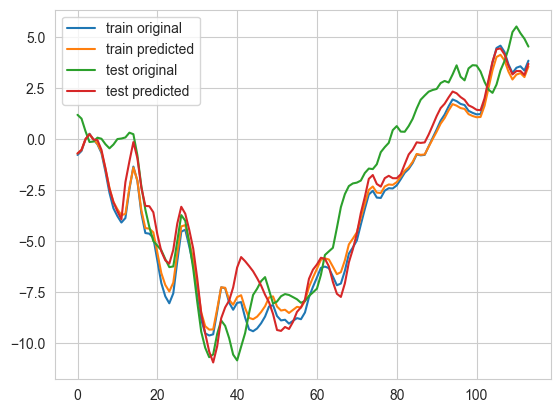

In [175]:
plt.plot(np.mean(train_original_cvs, axis=0), label = 'train original')
plt.plot(np.mean(train_predicted_cvs, axis=0), label = 'train predicted')

plt.plot(np.mean(test_original_cvs, axis=0), label = 'test original')
plt.plot(np.mean(test_predicted_cvs, axis=0), label = 'test predicted')

plt.legend()

0.4727772139078199
0.5961279689156039


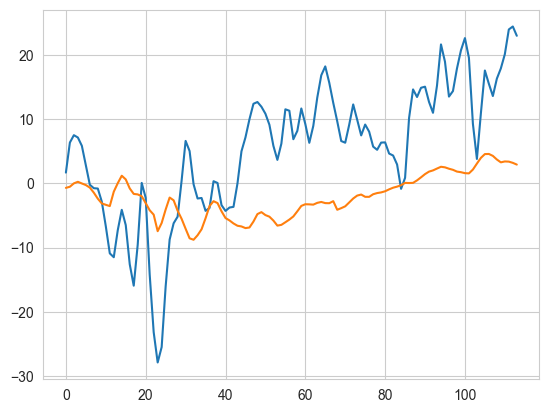

In [176]:
plt.plot(single_trial_train_org)
plt.plot(single_trial_train_pred)

print(np.corrcoef(single_trial_train_org, single_trial_train_pred)[0,1]) # train vs predicted
print(np.corrcoef(single_trial_org, single_trial_pred)[0,1]) # test vs predicted

In [177]:
splits_corrs_train = np.array(splits_corrs_train)
splits_corrs_test = np.array(splits_corrs_test)

Test correlations mean: 0.33182420250207995
Train correlations mean: 0.37881385909033094


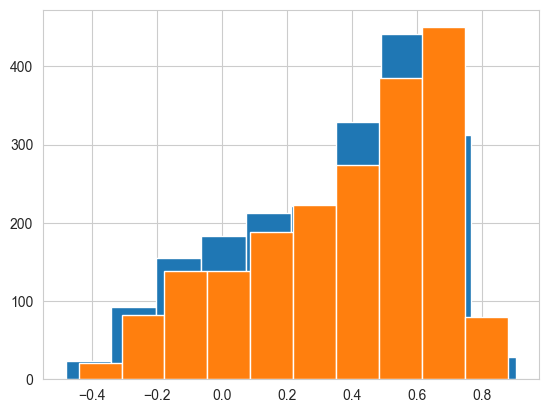

In [178]:
plt.hist(splits_corrs_test.flatten())
plt.hist(splits_corrs_train.flatten())

print(f"Test correlations mean: {np.mean(splits_corrs_test)}")
print(f"Train correlations mean: {np.mean(splits_corrs_train)}")

---
## Compare models

In [15]:
# TODO

In [36]:
# Configure the logger
logging.basicConfig(
    level=logging.INFO,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

In [37]:
def calculate_brain_score(
        cv_results,
        test=True,
        crop=(0,0.5),
        sfreq=64,
        epoch_lim = (-0.2, 1.58)
):
    if test:
        variable = 'test'
    else:
        variable = 'train'

    person_results = {}
    for channel in cv_results.keys():
        test_original_cvs = cv_results[channel][f'{variable}_original'].to_numpy()
        test_predicted_cvs = cv_results[channel][f'{variable}_predicted'].to_numpy()

        # epochs: -0.2 to 1.58 ms -> 0 to 114
        if crop is None:
            t_min, t_max = epoch_lim
        else:
            t_min, t_max = crop

        # calculate time window in timepoints
        t_min_tp = int((t_min - epoch_lim[0])*sfreq)
        t_max_tp = int((t_max - epoch_lim[0])*sfreq)

        # iterate over cv repeats
        cv_pearsons_r = []
        for i, (original, predicted) in enumerate(zip(test_original_cvs, test_predicted_cvs)):
            original_cropped = np.array(original)[:, t_min_tp:t_max_tp]
            predicted_cropped = np.array(predicted)[:, t_min_tp:t_max_tp]

            original_cropped_flatten = original_cropped.flatten()
            predicted_cropped_flatten = predicted_cropped.flatten()

            # calculate pearsons r
            r = np.corrcoef(original_cropped_flatten, predicted_cropped_flatten)[0, 1]
            cv_pearsons_r.append(r)

        cv_pearsons_r = np.array(cv_pearsons_r)
        r_mean = cv_pearsons_r.mean()
        r_sd = cv_pearsons_r.std()

        person_results[channel] = {'cv_pearsons_r': cv_pearsons_r, 'cv_mean': r_mean, 'cv_std': r_sd}

    return person_results

In [38]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


Test

In [40]:
file_names = file_names[:6]
results_main_path = '../data/cv_ridge'

unfold_models = ['baseline', 
                 'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
                 'full_stop_type_sri', 'full_interactions'
                 ]

models_results_aggregation = []
for file_name in file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score(
                cv_results,
                test=True,
                crop=(.7, 1.5)
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

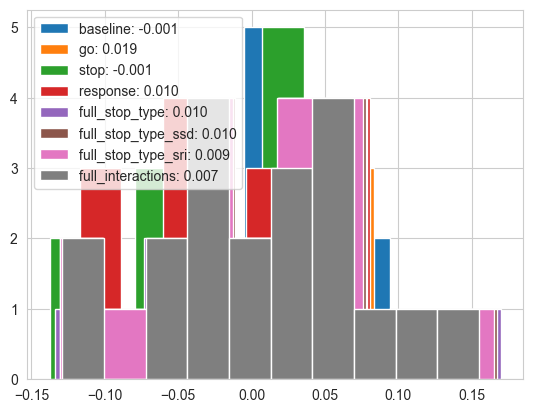

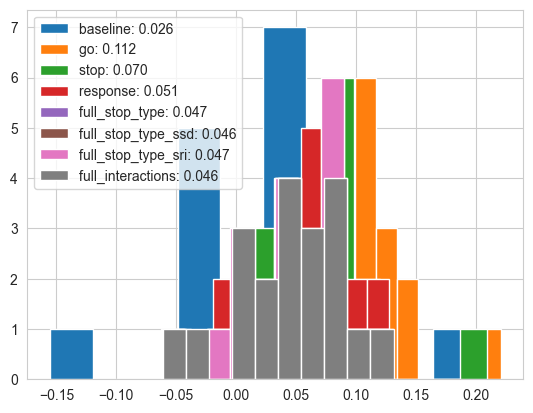

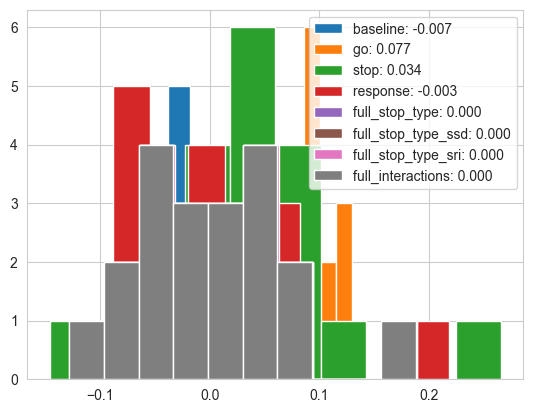

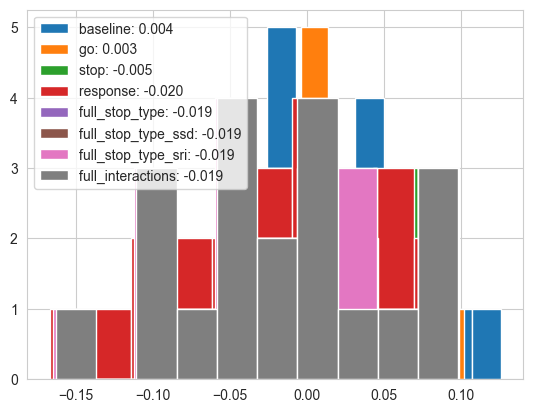

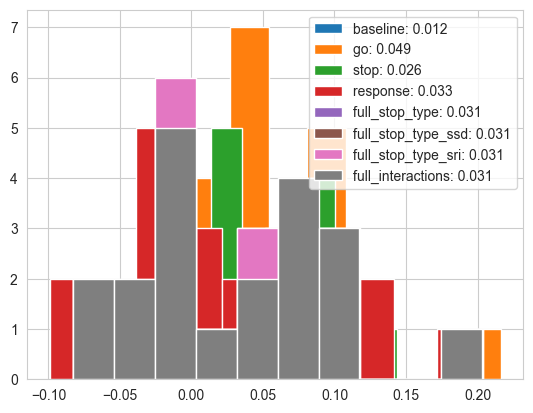

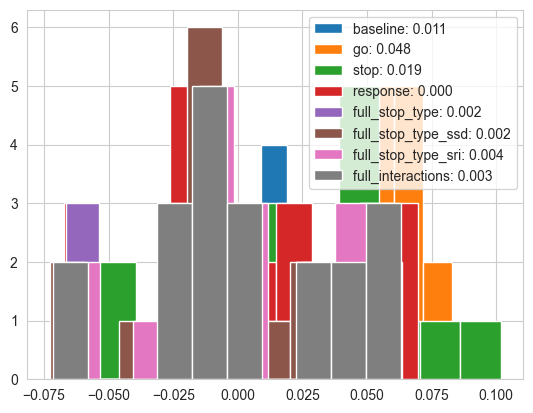

In [41]:
channel = 'Fz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    for model_name, pearsons_r_results in person_results.items():
        data = pearsons_r_results[channel]['cv_pearsons_r']
        plt.hist(data, label=f"{model_name}: {np.mean(data):.3f}")

    plt.legend()

Plot results - within people aggregations

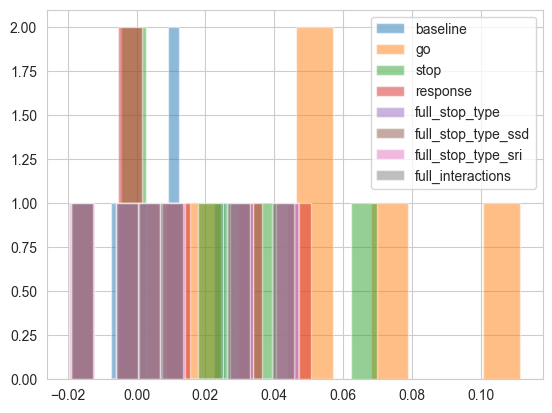

In [42]:
channel = 'Fz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Plot the histograms
for model_name, results in person_model_agg.items():
    plt.hist(results, label=model_name, alpha=0.5)  # Use alpha for better overlay visibility
plt.legend()

#### Train

In [43]:
file_names = file_names[:6]
results_main_path = '../data/cv_ridge'

unfold_models = ['baseline', 'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
                 'full_stop_type_sri', 'full_interactions']

models_results_aggregation = []
for file_name in file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score(
                cv_results,
                test=False,
                crop=None
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

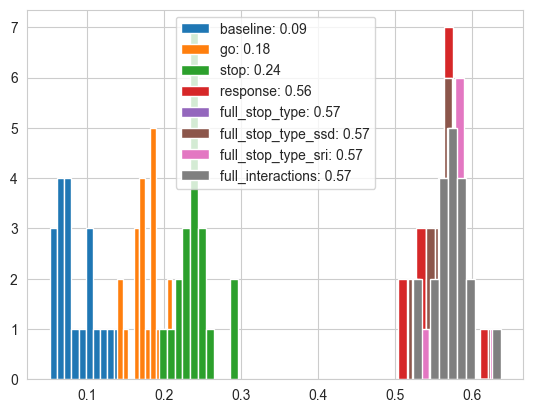

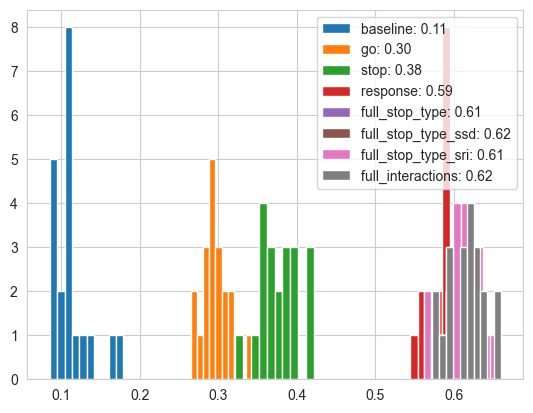

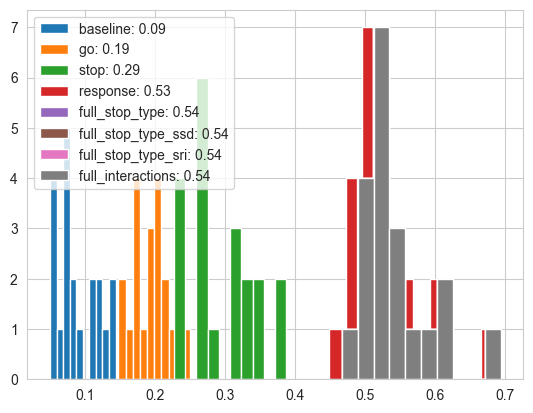

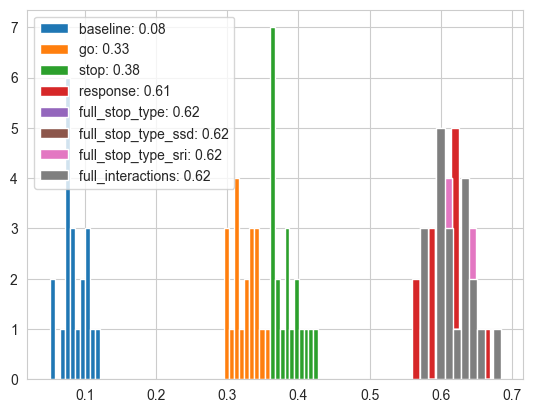

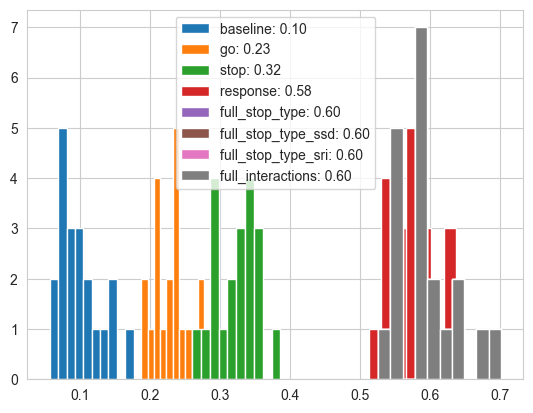

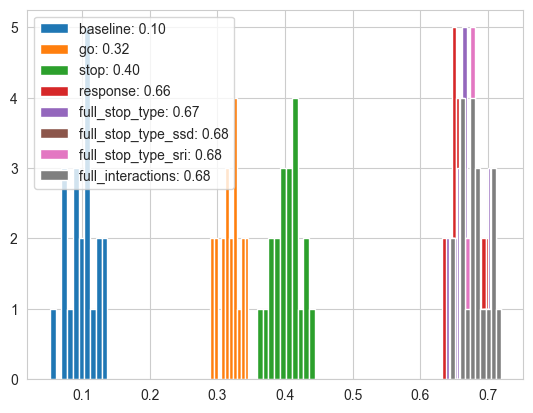

In [44]:
channel = 'Fz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    for model_name, pearsons_r_results in person_results.items():
        data = pearsons_r_results[channel]['cv_pearsons_r']
        plt.hist(data, label=f"{model_name}: {np.mean(data):.2f}")


    plt.legend()

Plot results - within people aggregations


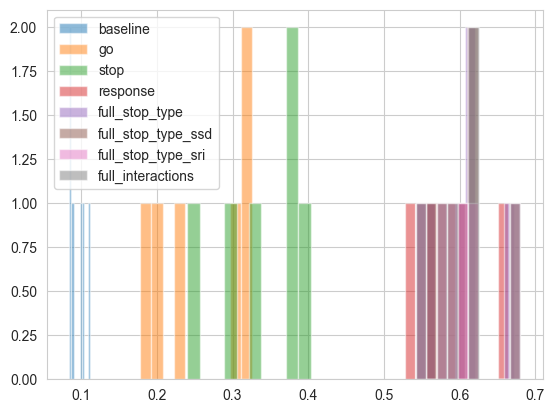

In [45]:
channel = 'Fz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Plot the histograms
for model_name, results in person_model_agg.items():
    plt.hist(results, label=model_name, alpha=0.5)  # Use alpha for better overlay visibility
plt.legend()